In [1]:
# Step 1 - Install Dependencies

# Install core training libraries
!pip install -q transformers==4.45.0
!pip install -q datasets==3.0.1
!pip install -q peft==0.13.0
!pip install -q trl==0.11.4
!pip install -q accelerate==0.34.2

# Install evaluation libraries
!pip install -q rouge-score
!pip install -q bert-score
!pip install -q scikit-learn

# Install huggingface hub
!pip install -q huggingface_hub

print("All packages installed successfully")

All packages installed successfully


In [2]:
# Step 2 - Check GPU

import torch

# Check if GPU is available
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Print GPU details if available
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("GPU memory:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2), "GB")
else:
    print("No GPU found - please switch to A100 runtime")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU name: NVIDIA A100-SXM4-80GB
GPU memory: 85.09 GB


In [3]:
# Step 3 - Mount Google Drive

from google.colab import drive

# Mount drive
drive.mount('/content/drive')

# Define base project path
base_path = '/content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/phi35_lora'

# Define all sub folder paths
adapter_path   = base_path + '/adapter'
results_path   = base_path + '/results'
plots_path     = base_path + '/plots'
checkpoint_path = base_path + '/checkpoints'

# Create all folders if they do not exist
import os
for path in [adapter_path, results_path, plots_path, checkpoint_path]:
    os.makedirs(path, exist_ok=True)

print("Drive mounted successfully")
print("Project path:", base_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully
Project path: /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/phi35_lora


In [4]:
# Step 4 - Authenticate Hugging Face

from huggingface_hub import login
from google.colab import userdata

# Load HF token from Colab secrets and login
hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

print("Hugging Face authentication successful")

Hugging Face authentication successful


In [5]:
# Step 5 - Load Dataset from Hugging Face JSONL files

from datasets import load_dataset, DatasetDict

# Define base path to processed folder on Hugging Face
base_url = "hf://datasets/BSVGK/Text_to_KG_Construction_Dataset/processed/"

# Load each pre-defined split directly from its JSONL file
print("Loading dataset...")

dataset = DatasetDict({
    'train'      : load_dataset('json', data_files=base_url + 'train.jsonl',      split='train'),
    'validation' : load_dataset('json', data_files=base_url + 'validation.jsonl', split='train'),
    'test'       : load_dataset('json', data_files=base_url + 'test.jsonl',       split='train')
})

# Print number of records per split
print("Dataset loaded successfully")
print("Train records     :", len(dataset['train']))
print("Validation records:", len(dataset['validation']))
print("Test records      :", len(dataset['test']))

# Print one sample to verify
print("\nSample record:")
print("Instruction:", dataset['train'][0]['instruction'])
print("Input      :", dataset['train'][0]['input'])
print("Output     :", dataset['train'][0]['output'])

Loading dataset...
Dataset loaded successfully
Train records     : 6470
Validation records: 1387
Test records      : 1387

Sample record:
Instruction: Extract entities and relationships from the construction contract description and represent them as triples.
Input      : A £420850 contract identified as Contract_008672 in Yorkshire and the Humber was awarded to AMALGAMATED CONSTRUCTION LTD by Wakefield Council Customer Service. The award date was 2017-12-05, and the contract is associated with CPV code 71322000 for Engineering design services for the construction of civil engineering works.
Output     : (Contract_008672, rdf:type, Contract)
(Contract_008672, hasBuyer, Wakefield Council Customer Service)
(Contract_008672, hasSupplier, AMALGAMATED CONSTRUCTION LTD)
(Contract_008672, hasContractValue, 420850)
(Contract_008672, hasAwardDate, 2017-12-05)
(Contract_008672, hasCPVCode, 71322000)
(Contract_008672, hasCPVDescription, Engineering design services for the construction of civil en

In [6]:
# Step 6 - Load Ontology Schema

import json
from huggingface_hub import hf_hub_download

# Download ontology schema from Hugging Face
ontology_file = hf_hub_download(
    repo_id   = "BSVGK/Text_to_KG_Construction_Dataset",
    filename  = "processed/ontology_schema.json",
    repo_type = "dataset"
)

# Load ontology schema
with open(ontology_file, 'r') as f:
    ontology = json.load(f)

# Print ontology structure
print("Ontology schema loaded successfully")
print("Ontology contents:")
print(json.dumps(ontology, indent=2))

Ontology schema loaded successfully
Ontology contents:
{
  "classes": {
    "Contract": "A public construction contract record.",
    "Buyer": "The organisation purchasing or awarding the contract.",
    "Supplier": "The organisation awarded the contract.",
    "CPVCategory": "The procurement classification category.",
    "Location": "The geographical location linked to the contract."
  },
  "relationships": {
    "hasBuyer": "Links a contract to the buying organisation.",
    "hasSupplier": "Links a contract to the awarded supplier.",
    "hasContractValue": "Stores the monetary value of the contract.",
    "hasAwardDate": "Stores the contract award date.",
    "hasCPVCode": "Stores the CPV classification code.",
    "hasCPVDescription": "Stores the CPV category description.",
    "hasLocation": "Stores the contract location."
  }
}


In [7]:
# Step 7 - Load Model and Tokenizer

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Define model name
model_name = "microsoft/Phi-3.5-mini-instruct"

# Load tokenizer
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(
    model_name,
    trust_remote_code=True,
    padding_side="right"
)

# Set pad token to eos token if not defined
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

print("Tokenizer loaded successfully")
print("Vocab size :", tokenizer.vocab_size)
print("Pad token  :", tokenizer.pad_token)
print("EOS token  :", tokenizer.eos_token)

# Load model in float16 for A100
print("\nLoading model...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype       = torch.float16,
    device_map        = "auto",
    trust_remote_code = True,
    attn_implementation = "eager"
)

# Disable cache for training
model.config.use_cache       = False
model.config.pretraining_tp  = 1

# Print model info
total_params = sum(p.numel() for p in model.parameters())
print("Model loaded successfully")
print("Total parameters :", round(total_params / 1e9, 2), "B")
print("Memory used      :", round(torch.cuda.memory_allocated() / 1e9, 2), "GB")

Loading tokenizer...
Tokenizer loaded successfully
Vocab size : 32000
Pad token  : <|endoftext|>
EOS token  : <|endoftext|>

Loading model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded successfully
Total parameters : 3.82 B
Memory used      : 7.64 GB


In [8]:
# Step 8 - Apply LoRA Configuration

from peft import LoraConfig, get_peft_model, TaskType

# Define LoRA configuration
lora_config = LoraConfig(
    r              = 16,
    lora_alpha     = 32,
    lora_dropout   = 0.05,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
    # Target attention and feed forward layers in Phi-3.5
    target_modules = [
        "q_proj", "k_proj", "v_proj",
        "o_proj", "gate_proj",
        "up_proj", "down_proj"
    ]
)

# Apply LoRA to model
model = get_peft_model(model, lora_config)

# Calculate trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())
frozen_params    = total_params - trainable_params

print("LoRA applied successfully")
print("Trainable parameters :", f"{trainable_params:,}")
print("Frozen parameters    :", f"{frozen_params:,}")
print("Total parameters     :", f"{total_params:,}")
print("Trainable percentage :", round(100 * trainable_params / total_params, 4), "%")

LoRA applied successfully
Trainable parameters : 8,912,896
Frozen parameters    : 3,821,079,552
Total parameters     : 3,829,992,448
Trainable percentage : 0.2327 %


In [9]:
# Step 9 - Prepare Dataset and Prompt Format

# Format each record into Phi-3.5 chat format
def format_prompt(example):
    # Build prompt using Phi-3.5 native chat template
    prompt = f"""<|user|>
{example['instruction']}

Contract Description:
{example['input']}<|end|>
<|assistant|>
{example['output']}<|end|>"""

    return {"text": prompt}

# Apply formatting to all splits
print("Formatting dataset...")
train_dataset = dataset['train'].map(format_prompt,      remove_columns=dataset['train'].column_names)
val_dataset   = dataset['validation'].map(format_prompt, remove_columns=dataset['validation'].column_names)
test_dataset  = dataset['test'].map(format_prompt,       remove_columns=dataset['test'].column_names)

print("Dataset formatted successfully")
print("Train records     :", len(train_dataset))
print("Validation records:", len(val_dataset))
print("Test records      :", len(test_dataset))

# Print one formatted sample to verify
print("\nSample formatted prompt:")
print(train_dataset[0]['text'])

Formatting dataset...


Map:   0%|          | 0/6470 [00:00<?, ? examples/s]

Map:   0%|          | 0/1387 [00:00<?, ? examples/s]

Map:   0%|          | 0/1387 [00:00<?, ? examples/s]

Dataset formatted successfully
Train records     : 6470
Validation records: 1387
Test records      : 1387

Sample formatted prompt:
<|user|>
Extract entities and relationships from the construction contract description and represent them as triples.

Contract Description:
A £420850 contract identified as Contract_008672 in Yorkshire and the Humber was awarded to AMALGAMATED CONSTRUCTION LTD by Wakefield Council Customer Service. The award date was 2017-12-05, and the contract is associated with CPV code 71322000 for Engineering design services for the construction of civil engineering works.<|end|>
<|assistant|>
(Contract_008672, rdf:type, Contract)
(Contract_008672, hasBuyer, Wakefield Council Customer Service)
(Contract_008672, hasSupplier, AMALGAMATED CONSTRUCTION LTD)
(Contract_008672, hasContractValue, 420850)
(Contract_008672, hasAwardDate, 2017-12-05)
(Contract_008672, hasCPVCode, 71322000)
(Contract_008672, hasCPVDescription, Engineering design services for the construction of 

In [10]:
# Step 10 - Configure Training Arguments

from trl import SFTConfig

# Define all training arguments
training_args = SFTConfig(
    # Output and saving
    output_dir          = checkpoint_path,

    # Training duration
    num_train_epochs    = 3,

    # Batch size and gradient
    per_device_train_batch_size = 4,
    per_device_eval_batch_size  = 4,
    gradient_accumulation_steps = 4,

    # Learning rate settings
    learning_rate       = 2e-4,
    lr_scheduler_type   = "cosine",
    warmup_ratio        = 0.05,
    weight_decay        = 0.01,
    max_grad_norm       = 0.3,

    # Sequence length
    max_seq_length      = 1024,

    # Logging and evaluation
    logging_steps       = 10,
    eval_steps          = 100,
    save_steps          = 100,

    # Use standard optimizer since bitsandbytes is not used
    optim               = "adamw_torch",
    fp16                = True,

    # Dataset and evaluation settings
    dataset_text_field  = "text",
    eval_strategy       = "steps",
    save_strategy       = "steps",
    load_best_model_at_end = True,
    metric_for_best_model  = "eval_loss",
    greater_is_better      = False,
    save_total_limit       = 2,

    # Disable external reporting
    report_to           = "none",
    packing             = False,
    logging_dir         = plots_path,
)

print("Training arguments configured successfully")
print("Epochs          :", training_args.num_train_epochs)
print("Batch size      :", training_args.per_device_train_batch_size)
print("Learning rate   :", training_args.learning_rate)
print("Max seq length  :", training_args.max_seq_length)
print("Optimizer       :", training_args.optim)
print("Checkpoint path :", checkpoint_path)

Training arguments configured successfully
Epochs          : 3
Batch size      : 4
Learning rate   : 0.0002
Max seq length  : 1024
Optimizer       : OptimizerNames.ADAMW_TORCH
Checkpoint path : /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/phi35_lora/checkpoints


In [11]:
# Step 11 - Initialize Trainer

from trl import SFTTrainer

# Initialize SFT Trainer with model, data and training arguments
trainer = SFTTrainer(
    model         = model,
    args          = training_args,
    train_dataset = train_dataset,
    eval_dataset  = val_dataset,
    tokenizer     = tokenizer,
)

# Calculate total training steps
total_steps = (len(train_dataset) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps)) * training_args.num_train_epochs

print("Trainer initialized successfully")
print("Total training samples :", len(train_dataset))
print("Total training steps   :", total_steps)
print("Eval every             :", training_args.eval_steps, "steps")
print("Save every             :", training_args.save_steps, "steps")
print("Best model metric      :", training_args.metric_for_best_model)

Map:   0%|          | 0/6470 [00:00<?, ? examples/s]

Map:   0%|          | 0/1387 [00:00<?, ? examples/s]

Trainer initialized successfully
Total training samples : 6470
Total training steps   : 1212
Eval every             : 100 steps
Save every             : 100 steps
Best model metric      : eval_loss


/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:494: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


In [12]:
# Step 12 - Start Training

import time

# Record start time
start_time = time.time()

print("Starting training...")
print("Model          : Phi-3.5 Mini Instruct")
print("Method         : LoRA")
print("Epochs         : 3")
print("Total steps    : 1212")
print("Logging every  : 10 steps")
print("Eval every     : 100 steps")
print("-" * 50)

# Start training
train_result = trainer.train()

# Calculate total training time
end_time     = time.time()
total_time   = round((end_time - start_time) / 60, 2)

# Print training summary
print("-" * 50)
print("Training completed successfully")
print("Total steps    :", train_result.global_step)
print("Training loss  :", round(train_result.training_loss, 4))
print("Training time  :", total_time, "minutes")

Starting training...
Model          : Phi-3.5 Mini Instruct
Method         : LoRA
Epochs         : 3
Total steps    : 1212
Logging every  : 10 steps
Eval every     : 100 steps
--------------------------------------------------


Step,Training Loss,Validation Loss
100,0.338200,0.331723
200,0.300600,0.301733
300,0.287700,0.287470
400,0.272200,0.278323
500,0.266900,0.273132
600,0.267000,0.267287
700,0.257200,0.263581
800,0.255000,0.260542
900,0.256200,0.259625
1000,0.247700,0.258217


--------------------------------------------------
Training completed successfully
Total steps    : 1212
Training loss  : 0.3008
Training time  : 26.01 minutes


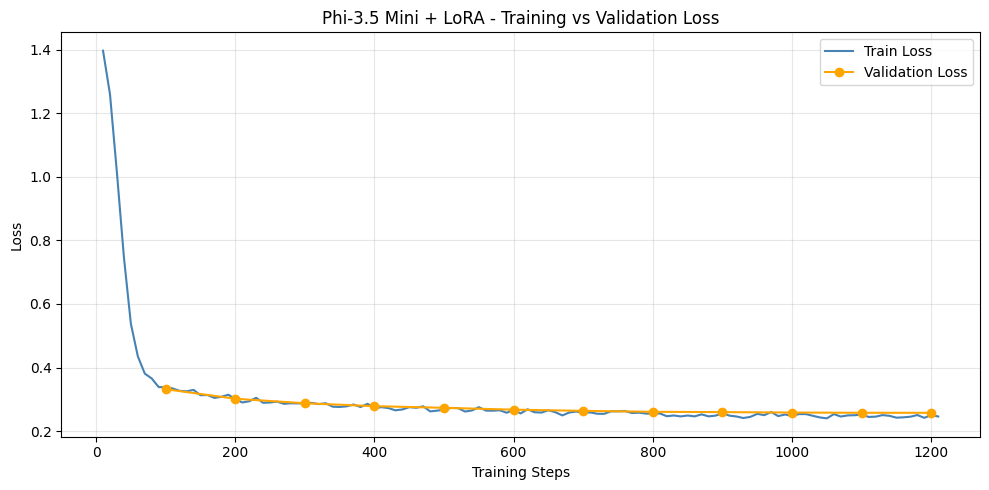

Loss curve saved to: /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/phi35_lora/plots/loss_curve.png


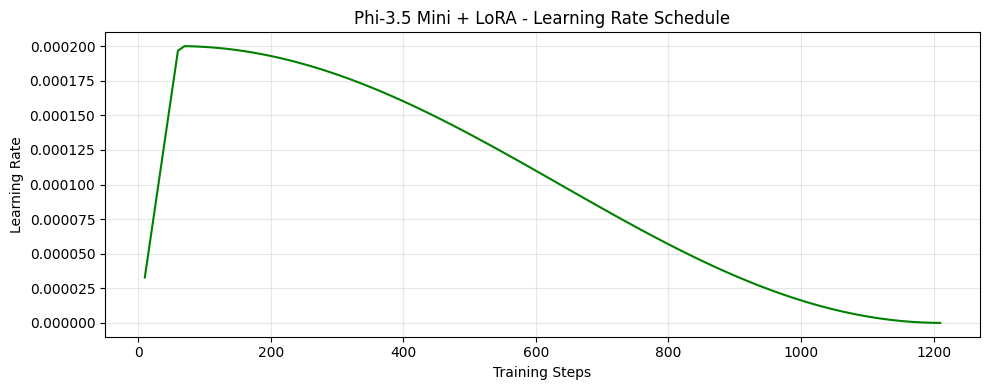

Learning rate schedule saved to: /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/phi35_lora/plots/lr_schedule.png


In [13]:
# Step 13 - Save Training Plots to Drive

import matplotlib.pyplot as plt

# Extract loss values from trainer log history
train_losses = [(x['step'], x['loss'])      for x in trainer.state.log_history if 'loss' in x]
eval_losses  = [(x['step'], x['eval_loss']) for x in trainer.state.log_history if 'eval_loss' in x]

# Separate steps and loss values
train_steps, train_loss_values = zip(*train_losses)
eval_steps,  eval_loss_values  = zip(*eval_losses)

# Plot train loss vs eval loss
plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss_values, label='Train Loss',      color='steelblue')
plt.plot(eval_steps,  eval_loss_values,  label='Validation Loss', color='orange', marker='o')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Phi-3.5 Mini + LoRA - Training vs Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save to Drive
loss_plot_path = plots_path + '/loss_curve.png'
plt.savefig(loss_plot_path, dpi=150)
plt.show()
print("Loss curve saved to:", loss_plot_path)

# Plot learning rate schedule
lr_values = [(x['step'], x['learning_rate']) for x in trainer.state.log_history if 'learning_rate' in x]
lr_steps, lr_vals = zip(*lr_values)

plt.figure(figsize=(10, 4))
plt.plot(lr_steps, lr_vals, color='green')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.title('Phi-3.5 Mini + LoRA - Learning Rate Schedule')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save to Drive
lr_plot_path = plots_path + '/lr_schedule.png'
plt.savefig(lr_plot_path, dpi=150)
plt.show()
print("Learning rate schedule saved to:", lr_plot_path)

In [14]:
# Step 14 - Save LoRA Adapter to Drive

import os

# Save LoRA adapter weights to Drive
print("Saving LoRA adapter to Drive...")
trainer.model.save_pretrained(adapter_path)

# Save tokenizer to same folder
print("Saving tokenizer to Drive...")
tokenizer.save_pretrained(adapter_path)

# Print saved files and sizes
print("\nAdapter saved successfully")
print("Adapter path:", adapter_path)
print("\nSaved files:")
for f in os.listdir(adapter_path):
    size = os.path.getsize(os.path.join(adapter_path, f)) / 1e6
    print(f"  {f} : {round(size, 2)} MB")

Saving LoRA adapter to Drive...
Saving tokenizer to Drive...

Adapter saved successfully
Adapter path: /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/phi35_lora/adapter

Saved files:
  README.md : 0.01 MB
  adapter_model.safetensors : 35.67 MB
  adapter_config.json : 0.0 MB
  tokenizer_config.json : 0.0 MB
  special_tokens_map.json : 0.0 MB
  added_tokens.json : 0.0 MB
  tokenizer.model : 0.5 MB
  tokenizer.json : 3.62 MB


In [19]:
# Step 15a - Test Inference on One Record to Verify Model Output

import torch

# Fix padding side for decoder only model
tokenizer.padding_side = "left"

# Set model to evaluation mode
model.eval()

# Pick one sample from test set
sample = dataset['test'][0]

# Build prompt
prompt = f"""<|user|>
{sample['instruction']}

Contract Description:
{sample['input']}<|end|>
<|assistant|>
"""

# Tokenize
inputs = tokenizer(
    prompt,
    return_tensors = "pt",
    truncation     = True,
    max_length     = 800
).to(model.device)

# Generate prediction
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens     = 200,
        do_sample          = False,
        repetition_penalty = 1.1,
        pad_token_id       = tokenizer.pad_token_id,
        eos_token_id       = tokenizer.eos_token_id,
    )

# Decode output
input_length = inputs.input_ids.shape[1]
predicted    = tokenizer.decode(
    outputs[0][input_length:],
    skip_special_tokens = True
).strip()

# Print results
print("Input:")
print(sample['input'])
print("\nPredicted Triples:")
print(predicted)
print("\nGround Truth Triples:")
print(sample['output'])

Input:
Greater London Authority selected Happy Energy Solutions Ltd for contract Contract_001489 in London. The work is described as Heating works, with CPV code 45232141, awarded on 2019-12-10, and valued at £13970000.

Predicted Triples:
(Contract_001489, rdf:type, Contract)
(Contract_001489, hasBuyer, Greater London Authority)
(Contract_001489, hasSupplier, Happy Energy Solutions Ltd)
(Contract_001489, hasContractValue, 13970000)
(Contract_001489, hasAwardDate, 2019-12-10)
(Contract_001489, hasCPVCode, 45232141)
(Contract_001489, hasCPVDescription, Heating works)
(Contract_001489, hasLocation, London)

Ground Truth Triples:
(Contract_001489, rdf:type, Contract)
(Contract_001489, hasBuyer, Greater London Authority)
(Contract_001489, hasSupplier, Happy Energy Solutions Ltd)
(Contract_001489, hasContractValue, 13970000)
(Contract_001489, hasAwardDate, 2019-12-10)
(Contract_001489, hasCPVCode, 45232141)
(Contract_001489, hasCPVDescription, Heating works)
(Contract_001489, hasLocation, L

In [21]:
# Step 15b - Run Inference on Full Test Set using Batch Inference

import torch

# Fix padding side for decoder only model
tokenizer.padding_side = "left"

# Set model to evaluation mode
model.eval()

# Batch size for inference
INFERENCE_BATCH_SIZE = 8

# Build prompt for each sample
def build_prompt(sample):
    return f"""<|user|>
{sample['instruction']}

Contract Description:
{sample['input']}<|end|>
<|assistant|>
"""

# Prepare all prompts and ground truths from full test set
print("Building prompts...")
prompts       = [build_prompt(s) for s in dataset['test']]
ground_truths = [s['output'] for s in dataset['test']]
input_texts   = [s['input']  for s in dataset['test']]

total_samples = len(prompts)
print("Total test samples:", total_samples)
print("Running batch inference...")
print("Batch size        :", INFERENCE_BATCH_SIZE)
print("-" * 40)

predictions = []

for i in range(0, total_samples, INFERENCE_BATCH_SIZE):
    # Get current batch of prompts
    batch_prompts = prompts[i : i + INFERENCE_BATCH_SIZE]

    # Tokenize batch with left padding
    inputs = tokenizer(
        batch_prompts,
        return_tensors = "pt",
        truncation     = True,
        padding        = True,
        max_length     = 800
    ).to(model.device)

    # Generate predictions for batch
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens     = 200,
            do_sample          = False,
            repetition_penalty = 1.1,
            pad_token_id       = tokenizer.pad_token_id,
            eos_token_id       = tokenizer.eos_token_id,
        )

    # Decode each output in the batch
    input_length = inputs.input_ids.shape[1]
    for output in outputs:
        generated = tokenizer.decode(
            output[input_length:],
            skip_special_tokens = True
        ).strip()
        predictions.append(generated)

    # Track and print progress every 100 samples
    processed = min(i + INFERENCE_BATCH_SIZE, total_samples)
    if processed % 100 < INFERENCE_BATCH_SIZE or processed == total_samples:
        print(f"Processed {processed} / {total_samples} samples")

print("-" * 40)
print("Inference completed successfully")
print("Total predictions:", len(predictions))

# Show one sample to verify
print("\nSample prediction:")
print("Input        :", input_texts[0])
print("\nPredicted    :", predictions[0])
print("\nGround truth :", ground_truths[0])

Building prompts...
Total test samples: 1387
Running batch inference...
Batch size        : 8
----------------------------------------
Processed 104 / 1387 samples
Processed 200 / 1387 samples
Processed 304 / 1387 samples
Processed 400 / 1387 samples
Processed 504 / 1387 samples
Processed 600 / 1387 samples
Processed 704 / 1387 samples
Processed 800 / 1387 samples
Processed 904 / 1387 samples
Processed 1000 / 1387 samples
Processed 1104 / 1387 samples
Processed 1200 / 1387 samples
Processed 1304 / 1387 samples
Processed 1387 / 1387 samples
----------------------------------------
Inference completed successfully
Total predictions: 1387

Sample prediction:
Input        : Greater London Authority selected Happy Energy Solutions Ltd for contract Contract_001489 in London. The work is described as Heating works, with CPV code 45232141, awarded on 2019-12-10, and valued at £13970000.

Predicted    : (Contract_001489, rdf:type, Contract)
(Contract_001489, hasBuyer, Greater London Authority)


In [22]:
# Step 16 - Compute All Evaluation Metrics

import re
import numpy as np
from rouge_score import rouge_scorer
from bert_score import score as bert_score

# Define valid relations from ontology for hallucination check
valid_relations = [
    "rdf:type",
    "hasBuyer",
    "hasSupplier",
    "hasContractValue",
    "hasAwardDate",
    "hasCPVCode",
    "hasCPVDescription",
    "hasLocation"
]

# Parse triples from output text into a list of tuples
def parse_triples(text):
    triples = []
    for line in text.strip().split('\n'):
        line = line.strip()
        if line.startswith('(') and line.endswith(')'):
            # Remove brackets and split by comma
            content = line[1:-1].split(',')
            if len(content) == 3:
                triple = tuple(part.strip() for part in content)
                triples.append(triple)
    return triples

# Compute precision recall and f1 for one sample
def compute_prf(pred_triples, gt_triples):
    pred_set = set(pred_triples)
    gt_set   = set(gt_triples)

    if not pred_set and not gt_set:
        return 1.0, 1.0, 1.0
    if not pred_set or not gt_set:
        return 0.0, 0.0, 0.0

    tp        = len(pred_set & gt_set)
    precision = tp / len(pred_set)
    recall    = tp / len(gt_set)
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return precision, recall, f1

# Check hallucination level 1 - relation not in ontology
def check_hallucination_level1(pred_triples):
    hallucinated = 0
    total        = len(pred_triples)
    for triple in pred_triples:
        if triple[1] not in valid_relations:
            hallucinated += 1
    return hallucinated / total if total > 0 else 0.0

# Check hallucination level 2 - entity value not in input text
def check_hallucination_level2(pred_triples, input_text):
    hallucinated = 0
    total        = len(pred_triples)
    for triple in pred_triples:
        # Check if subject or object appears in input text
        subject = triple[0].lower()
        obj     = triple[2].lower()
        input_lower = input_text.lower()
        if subject not in input_lower and obj not in input_lower:
            hallucinated += 1
    return hallucinated / total if total > 0 else 0.0

# Compute all metrics
print("Computing evaluation metrics...")
print("Total samples:", len(predictions))
print("-" * 40)

precision_scores   = []
recall_scores      = []
f1_scores          = []
hallucination_l1   = []
hallucination_l2   = []

for i in range(len(predictions)):
    pred_triples = parse_triples(predictions[i])
    gt_triples   = parse_triples(ground_truths[i])

    # Compute precision recall f1
    p, r, f1 = compute_prf(pred_triples, gt_triples)
    precision_scores.append(p)
    recall_scores.append(r)
    f1_scores.append(f1)

    # Compute hallucination level 1
    h1 = check_hallucination_level1(pred_triples)
    hallucination_l1.append(h1)

    # Compute hallucination level 2
    h2 = check_hallucination_level2(pred_triples, input_texts[i])
    hallucination_l2.append(h2)

print("Precision, Recall, F1 and Hallucination computed")

# Compute ROUGE-L scores
print("Computing ROUGE-L scores...")
scorer       = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
rouge_scores = []
for pred, gt in zip(predictions, ground_truths):
    score = scorer.score(gt, pred)
    rouge_scores.append(score['rougeL'].fmeasure)

print("ROUGE-L computed")

# Compute BERTScore on full output string
print("Computing BERTScore...")
P, R, F1_bert = bert_score(
    predictions,
    ground_truths,
    lang          = "en",
    verbose       = False,
    device        = "cuda"
)
bert_scores = F1_bert.tolist()
print("BERTScore computed")

# Print all results
print("-" * 40)
print("EVALUATION RESULTS - Phi-3.5 Mini + LoRA")
print("-" * 40)
print("Primary Metrics:")
print("  F1 Score  :", round(np.mean(f1_scores),  4))
print("  Recall    :", round(np.mean(recall_scores), 4))
print("\nSecondary Metrics:")
print("  Precision          :", round(np.mean(precision_scores),  4))
print("  ROUGE-L            :", round(np.mean(rouge_scores),      4))
print("  BERTScore          :", round(np.mean(bert_scores),       4))
print("  Hallucination L1   :", round(np.mean(hallucination_l1),  4))
print("  Hallucination L2   :", round(np.mean(hallucination_l2),  4))
print("-" * 40)

Computing evaluation metrics...
Total samples: 1387
----------------------------------------
Precision, Recall, F1 and Hallucination computed
Computing ROUGE-L scores...
ROUGE-L computed
Computing BERTScore...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore computed
----------------------------------------
EVALUATION RESULTS - Phi-3.5 Mini + LoRA
----------------------------------------
Primary Metrics:
  F1 Score  : 0.9954
  Recall    : 0.995

Secondary Metrics:
  Precision          : 0.9959
  ROUGE-L            : 0.9991
  BERTScore          : 0.9997
  Hallucination L1   : 0.0
  Hallucination L2   : 0.0
----------------------------------------


In [23]:
# Step 17 - Save Results to Drive

import pandas as pd
import numpy as np
import os

# Compile all metrics into a dictionary
results = {
    'Model'            : 'Phi-3.5 Mini Instruct',
    'Method'           : 'LoRA',
    'LoRA Rank'        : 16,
    'LoRA Alpha'       : 32,
    'Epochs'           : 3,
    'Learning Rate'    : 2e-4,
    'Train Samples'    : len(dataset['train']),
    'Test Samples'     : len(predictions),
    'F1 Score'         : round(np.mean(f1_scores),         4),
    'Recall'           : round(np.mean(recall_scores),     4),
    'Precision'        : round(np.mean(precision_scores),  4),
    'ROUGE-L'          : round(np.mean(rouge_scores),      4),
    'BERTScore'        : round(np.mean(bert_scores),       4),
    'Hallucination L1' : round(np.mean(hallucination_l1),  4),
    'Hallucination L2' : round(np.mean(hallucination_l2),  4),
    'Training Loss'    : round(train_result.training_loss, 4),
    'Training Time'    : '26.01 minutes',
}

# Convert to dataframe
df_results = pd.DataFrame([results])

# Save to Drive
results_csv_path = results_path + '/metrics.csv'
df_results.to_csv(results_csv_path, index=False)

print("Results saved successfully")
print("Results path:", results_csv_path)
print("\nFinal Results Table:")
print("-" * 40)
for key, value in results.items():
    print(f"  {key:<20} : {value}")
print("-" * 40)

Results saved successfully
Results path: /content/drive/MyDrive/Depixen/PROJECT_2_TEXT_TO_KG/phi35_lora/results/metrics.csv

Final Results Table:
----------------------------------------
  Model                : Phi-3.5 Mini Instruct
  Method               : LoRA
  LoRA Rank            : 16
  LoRA Alpha           : 32
  Epochs               : 3
  Learning Rate        : 0.0002
  Train Samples        : 6470
  Test Samples         : 1387
  F1 Score             : 0.9954
  Recall               : 0.995
  Precision            : 0.9959
  ROUGE-L              : 0.9991
  BERTScore            : 0.9997
  Hallucination L1     : 0.0
  Hallucination L2     : 0.0
  Training Loss        : 0.3008
  Training Time        : 26.01 minutes
----------------------------------------
